In [22]:
from matplotlib import pyplot as plt
import strategies
from tqdm import tqdm
from game import Game
import numpy as np

%matplotlib inline
%config InlineBackend.figure_format = 'svg'
plt.style.use('default')

In [23]:
def pretty_table(data):
    col_widths = [max(len(str(cell)) for cell in col) for col in zip(*data)]
    lines = [' | '.join(str(cell).ljust(width) for cell, width in zip(row, col_widths)) for row in data]
    sep = '-+-'.join('-' * width for width in col_widths)
    lines.insert(1, sep)
    return '\n'.join(lines)

def evaluate_strategy(strategy, num_trials=1000):
    results = []

    for _ in tqdm(range(num_trials)):
        game = Game()
        while not game.dead:
            game.play_strategy(strategy)
        results.append(game.move_count)

    return results

100%|██████████| 20/20 [00:00<00:00, 766.61it/s]


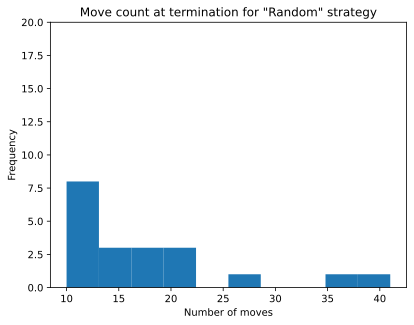

100%|██████████| 20/20 [00:00<00:00, 64.43it/s]


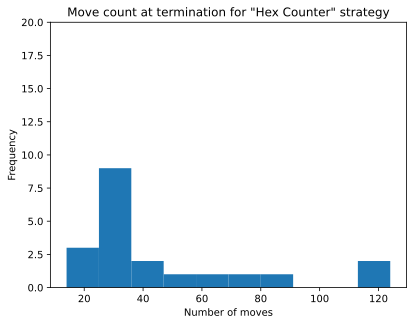

100%|██████████| 20/20 [00:16<00:00,  1.21it/s]


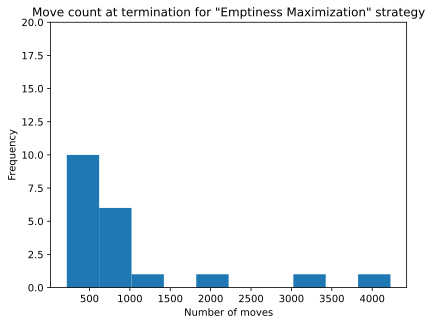

Strategy               | Mean Moves | Min Moves | Median Moves | Max Moves
-----------------------+------------+-----------+--------------+----------
Random                 | 18.05      | 10        | 16.0         | 41       
Hex Counter            | 45.95      | 14        | 34.0         | 124      
Emptiness Maximization | 962.55     | 219       | 642.5        | 4226     


In [24]:
strategies_to_evaluate = [
    strategies.Random(),
    strategies.HexCounter(),
    strategies.EmptinessMaximization(),
]

n = 20

results_arr = []
for strategy in strategies_to_evaluate:
    results = evaluate_strategy(strategy, num_trials=n)
    plt.title(f'Move count at termination for "{strategy.name}" strategy')
    plt.xlabel('Number of moves')
    plt.ylabel('Frequency')
    plt.ylim(0, n)
    plt.hist(results)
    plt.show()
    results_arr.append((strategy, results))

table = [
    ["Strategy", "Mean Moves", "Min Moves", "Median Moves", "Max Moves"],
    *[
        [strategy.name, sum(results) / len(results), min(results), np.median(results), max(results)]
        for strategy, results in results_arr
    ]
]

print(pretty_table(table))